In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_csv('shoreline_validation_results_crossval.csv')

# Display the first few rows and columns to understand the structure
print(df.head())
print(df.info())
print(df['experiment'].unique()) # Check for experiment identifiers if any

               experiment    site          direction       N       RMSE  \
0  fold0_DeepLabV3512x512  agrelo  oblique-rectified  106561  19.987866   
1  fold0_DeepLabV3512x512  agrelo  rectified-oblique   12891  11.810500   
2  fold0_DeepLabV3512x512  agrelo      oblique-truth  106561  14.330491   
3  fold0_DeepLabV3512x512  agrelo      truth-oblique    2635   4.204698   
4  fold0_DeepLabV3512x512  agrelo    rectified-truth   12891  13.582496   

         MAE         Q3         SD  
0  10.269259  12.220492  17.148174  
1   4.606936   2.968850  10.875350  
2   6.132555   3.772549  12.952078  
3   2.306501   2.714427   3.516280  
4   6.013336   4.329012  12.179306  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   experiment  180 non-null    object 
 1   site        180 non-null    object 
 2   direction   180 non-null    object 
 3   N           1

In [2]:
# Display columns to identify correct names
print(df.columns)
print(df.head())

Index(['experiment', 'site', 'direction', 'N', 'RMSE', 'MAE', 'Q3', 'SD'], dtype='object')
               experiment    site          direction       N       RMSE  \
0  fold0_DeepLabV3512x512  agrelo  oblique-rectified  106561  19.987866   
1  fold0_DeepLabV3512x512  agrelo  rectified-oblique   12891  11.810500   
2  fold0_DeepLabV3512x512  agrelo      oblique-truth  106561  14.330491   
3  fold0_DeepLabV3512x512  agrelo      truth-oblique    2635   4.204698   
4  fold0_DeepLabV3512x512  agrelo    rectified-truth   12891  13.582496   

         MAE         Q3         SD  
0  10.269259  12.220492  17.148174  
1   4.606936   2.968850  10.875350  
2   6.132555   3.772549  12.952078  
3   2.306501   2.714427   3.516280  
4   6.013336   4.329012  12.179306  


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('shoreline_validation_results_crossval.csv')

direccions = ['rectified-truth', 'truth-rectified', 'oblique-truth', 'truth-oblique']

df_exp_crossval = df[
    df['direction'].isin(direccions)
].copy()

# Only keep all
df_exp_crossval = df_exp_crossval[df_exp_crossval['site'] == 'all']

print("\nExperiment 1 and 2 Results (All Sites):")
print("Experiment      | N       | Direction         |  MAE  | RMSE  |  Q3  ")
print("-----------------------------------------------------------")
for row in df_exp_crossval.itertuples():
    # Format and print the results
    print(f"{row.experiment:15} | {row.N:7} | {row.direction:17} | {row.MAE:5.2f} | {row.RMSE:5.2f} | {row.Q3:5.2f}")
    


Experiment 1 and 2 Results (All Sites):
Experiment      | N       | Direction         |  MAE  | RMSE  |  Q3  
-----------------------------------------------------------
fold0_DeepLabV3512x512 |  307637 | oblique-truth     |  5.01 | 11.39 |  4.15
fold0_DeepLabV3512x512 |   17322 | truth-oblique     |  4.64 |  8.20 |  5.72
fold0_DeepLabV3512x512 |   94002 | rectified-truth   |  5.48 |  9.71 |  5.82
fold0_DeepLabV3512x512 |   17322 | truth-rectified   |  4.44 |  7.81 |  5.05
fold1_DeepLabV3512x512 |  300468 | oblique-truth     |  4.00 |  8.68 |  3.72
fold1_DeepLabV3512x512 |   17322 | truth-oblique     |  4.90 | 11.59 |  5.51
fold1_DeepLabV3512x512 |   92140 | rectified-truth   |  4.71 |  7.38 |  5.66
fold1_DeepLabV3512x512 |   17322 | truth-rectified   |  4.06 |  6.46 |  5.14
fold2_DeepLabV3512x512 |  325530 | oblique-truth     |  5.85 | 12.83 |  5.32
fold2_DeepLabV3512x512 |   17322 | truth-oblique     |  5.65 |  9.36 |  6.97
fold2_DeepLabV3512x512 |   92800 | rectified-truth   |  5.0

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('shoreline_validation_results_crossval.csv')

# Define the target directions
directions = ['rectified-truth', 'truth-rectified', 'oblique-truth', 'truth-oblique']

# Filter the dataframe
df_exp_crossval = df[df['direction'].isin(directions)].copy()

# Only keep 'all' sites
df_exp_crossval = df_exp_crossval[df_exp_crossval['site'] == 'all']

# ==========================================
# CALCULATE MEAN AND STD ACROSS FOLDS
# ==========================================

print("\n" + "="*85)
print("STATISTICAL SUMMARY (Mean ± Std) across 5 Folds")
print("="*85)

# 1. Group by 'direction' and calculate Mean and Standard Deviation for metrics
# We select the columns MAE, RMSE, and Q3, then apply both 'mean' and 'std' functions
summary = df_exp_crossval.groupby('direction')[['MAE', 'RMSE', 'Q3', 'N']].agg(['mean', 'std'])

# 2. Print the table with a clean format
# Header
print(f"{'Direction':<17} | {'N (Mean ± SD)':<15} | {'MAE (Mean ± SD)':<17} | {'RMSE (Mean ± SD)':<17} | {'Q3 (Mean ± SD)':<20}")
print("-" * 85)

# Iterate through the results to format them nicely
for direction in summary.index:
    # Extract values for N
    N_mean = summary.loc[direction, ('N', 'mean')]
    N_std = summary.loc[direction, ('N', 'std')]

    # Extract values for MAE
    mae_mean = summary.loc[direction, ('MAE', 'mean')]
    mae_std = summary.loc[direction, ('MAE', 'std')]
    
    # Extract values for RMSE
    rmse_mean = summary.loc[direction, ('RMSE', 'mean')]
    rmse_std = summary.loc[direction, ('RMSE', 'std')]
    
    # Extract values for Q3
    q3_mean = summary.loc[direction, ('Q3', 'mean')]
    q3_std = summary.loc[direction, ('Q3', 'std')]

    # Print row formatted as "Value ± Deviation"
    print(f"{direction:<17} | {N_mean:5.2f} ± {N_std:4.2f}      | {mae_mean:5.2f} ± {mae_std:4.2f}      | {rmse_mean:5.2f} ± {rmse_std:4.2f}      | {q3_mean:5.2f} ± {q3_std:4.2f}")

print("-" * 85)


STATISTICAL SUMMARY (Mean ± Std) across 5 Folds
Direction         | N (Mean ± SD)   | MAE (Mean ± SD)   | RMSE (Mean ± SD)  | Q3 (Mean ± SD)      
-------------------------------------------------------------------------------------
oblique-truth     | 310474.80 ± 10314.92      |  4.82 ± 0.71      | 10.59 ± 1.58      |  4.35 ± 0.64
rectified-truth   | 93134.20 ± 964.47      |  5.03 ± 0.29      |  8.41 ± 0.86      |  5.65 ± 0.24
truth-oblique     | 17322.00 ± 0.00      |  5.18 ± 0.45      | 11.19 ± 2.50      |  5.98 ± 0.58
truth-rectified   | 17322.00 ± 0.00      |  4.19 ± 0.17      |  6.94 ± 0.53      |  5.01 ± 0.26
-------------------------------------------------------------------------------------


### Analysis

                experiment          site        direction       N       RMSE  \
2   fold0_DeepLabV3512x512        agrelo    oblique-truth  106561  14.330491   
4   fold0_DeepLabV3512x512        agrelo  rectified-truth   12891  13.582496   
8   fold0_DeepLabV3512x512  arenaldentem    oblique-truth   11306  11.363482   
10  fold0_DeepLabV3512x512  arenaldentem  rectified-truth    1602   4.608916   
14  fold0_DeepLabV3512x512         cadiz    oblique-truth  119703   9.143663   

         MAE         Q3         SD  
2   6.132555   3.772549  12.952078  
4   6.013336   4.329012  12.179306  
8   6.983429  10.020581   8.964794  
10  3.627974   4.941931   2.843405  
14  4.844889   5.339360   7.754619  


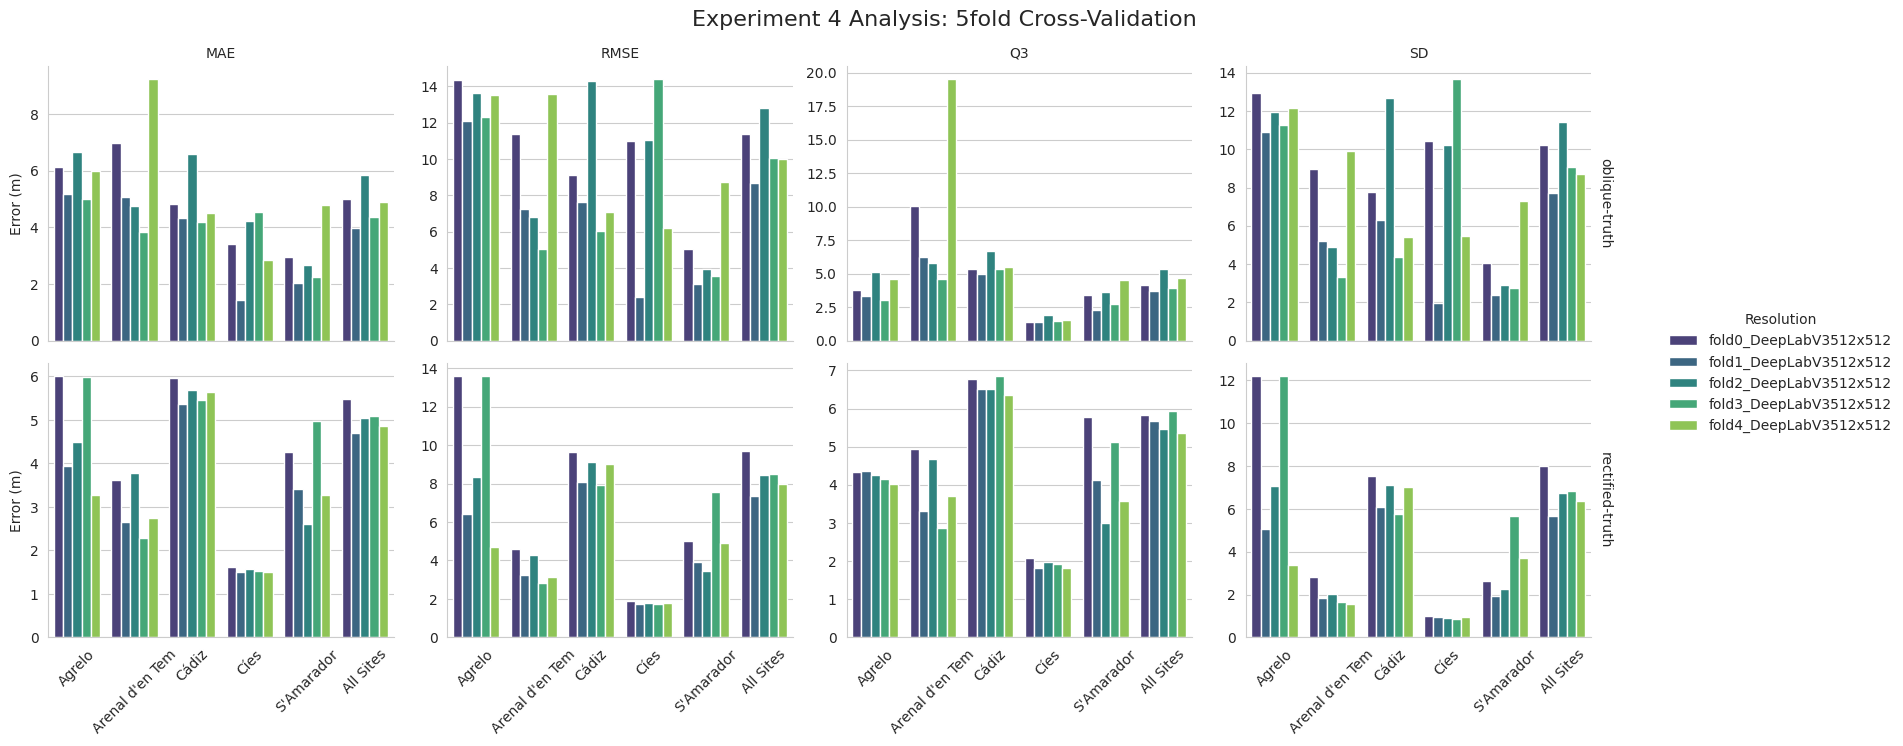

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('shoreline_validation_results_crossval.csv')

fold_filter = df['experiment'].str.contains('fold', case=False)
dir_filter = df['direction'].isin(['rectified-truth', 'oblique-truth'])
df_fold = df[fold_filter & dir_filter].copy()

print(df_fold.head())

# clean direction names
df_fold['Resolution'] = df_fold['experiment'].str.replace('fold_deeplabv3_', '')

site_mapping = {
    'agrelo': 'Agrelo',
    'arenaldentem': "Arenal d'en Tem",
    'cadiz': 'Cádiz',
    'cies': 'Cíes',
    'samarador': "S'Amarador",
    'all': 'All Sites'
}
df_fold['Site_Label'] = df_fold['site'].map(site_mapping).fillna(df_fold['site'].str.title())

metrics = ['MAE', 'RMSE', 'Q3', 'SD']
df_melted = df_fold.melt(
    id_vars=['Site_Label', 'direction', 'Resolution'], 
    value_vars=metrics, 
    var_name='Metric', 
    value_name='Value (m)'
)

sns.set_style("whitegrid")

g = sns.catplot(
    data=df_melted, 
    kind="bar",
    x="Site_Label", 
    y="Value (m)", 
    hue="Resolution",
    col="Metric", 
    row="direction",
    height=3.5, 
    aspect=1.2,
    palette="viridis", # O 'mako', 'rocket', etc.
    sharey=False,
    margin_titles=True
)

g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("", "Error (m)")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45) 

plt.subplots_adjust(top=0.9)
g.figure.suptitle('Experiment 4 Analysis: 5fold Cross-Validation', fontsize=16)

plt.show()

# save the figure
g.savefig('experiment4_crossval_metrics.png', dpi=300)


----------------------------------------
MAXIMUM VALUES PER STATION (METERS)
----------------------------------------
Agrelo               | Max: 14.19 m
Arenal d'en Tem      | Max: 15.07 m
Cádiz                | Max: 30.64 m
Cíes                 | Max: 5.07 m
S'Amarador           | Max: 4.74 m
All Sites            | Max: 26.62 m
----------------------------------------
Saving figures...


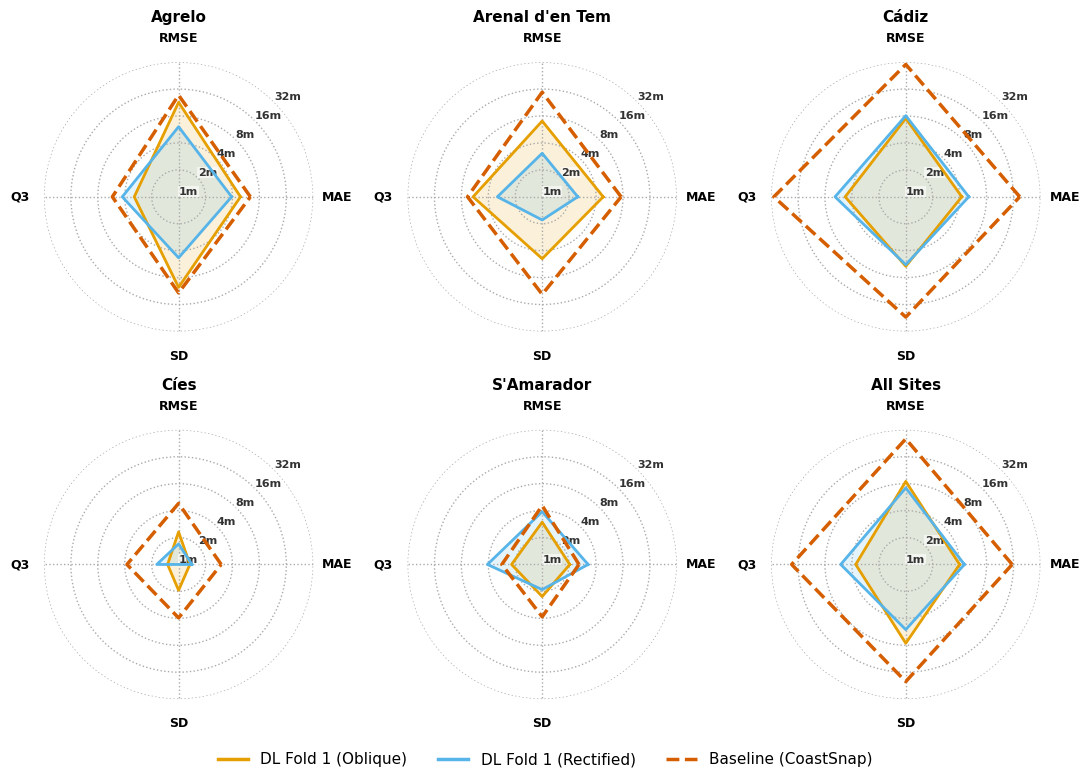

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from matplotlib.lines import Line2D
import os

# --- 1. LOAD DATA ---
try:
    df_crossval = pd.read_csv('shoreline_validation_results_crossval.csv')
    df_baseline = pd.read_csv('shoreline_validation_results_baseline.csv')
except FileNotFoundError:
    print("Warning: CSV files not found. Ensure the files are in the directory.")
    raise

# --- 2. DATA PREPARATION ---
fold_name = [x for x in df_crossval['experiment'].unique() if 'fold1' in str(x).lower().replace('_', '')][0]

df_dl = df_crossval[df_crossval['experiment'] == fold_name].copy()
df_dl = df_dl[df_dl['direction'].isin(['oblique-truth', 'rectified-truth'])].copy()

def get_dl_label(row):
    return 'DL Fold 1 (Oblique)' if 'oblique' in row['direction'] else 'DL Fold 1 (Rectified)'
df_dl['Label'] = df_dl.apply(get_dl_label, axis=1)

df_base = df_baseline[df_baseline['direction'] == 'rectified-truth'].copy()
df_base['Label'] = 'Baseline (CoastSnap)'

cols = ['site', 'Label', 'MAE', 'RMSE', 'Q3', 'SD']
df_combined = pd.concat([df_dl[cols], df_base[cols]], ignore_index=True)

site_mapping = {
    'agrelo': 'Agrelo', 
    'arenaldentem': "Arenal d'en Tem", 
    'cadiz': 'Cádiz', 
    'cies': 'Cíes', 
    'samarador': "S'Amarador", 
    'all': 'All Sites'
}
df_combined['Site_Label'] = df_combined['site'].map(site_mapping).fillna(df_combined['site'].str.title())

# --- 3. CONFIGURATION (LOG SCALE) ---
custom_ticks = [1, 2, 4, 8, 16, 32]
tick_indices = np.arange(len(custom_ticks))

def transform_equidistant(values):
    values = np.maximum(values, custom_ticks[0])
    return np.interp(values, custom_ticks, tick_indices)

max_grid = tick_indices[-1]

# --- 4. GENERATION OF GRAPHS (2 ROWS x 3 COLUMNS) ---
sites = ['Agrelo', "Arenal d'en Tem", 'Cádiz', 'Cíes', "S'Amarador", 'All Sites']
metrics = ['MAE', 'RMSE', 'Q3', 'SD']
n_metrics = len(metrics)
n_sites = len(sites)

labels_order = ['DL Fold 1 (Oblique)', 'DL Fold 1 (Rectified)', 'Baseline (CoastSnap)']
colors = {
    'DL Fold 1 (Oblique)': '#E69F00',
    'DL Fold 1 (Rectified)': '#56B4E9',
    'Baseline (CoastSnap)': '#D55E00'
}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(11, 8), subplot_kw=dict(polar=True))

# Flatten the axes array (2D -> 1D) to iterate easily
axes_flat = axes.flatten()

angles = [n / float(n_metrics) * 2 * pi for n in range(n_metrics)]
angles_closed = angles + angles[:1]

print("-" * 40)
print("MAXIMUM VALUES PER STATION (METERS)")
print("-" * 40)

for i, site in enumerate(sites):
    ax = axes_flat[i] # Use the flattened index
    site_data = df_combined[df_combined['Site_Label'] == site]

    if not site_data.empty:
        max_val = site_data[metrics].max().max()
        print(f"{site:<20} | Max: {max_val:.2f} m")
    
    for label in labels_order:
        subset = site_data[site_data['Label'] == label]
        if not subset.empty:
            raw_values = subset[metrics].values.flatten()
            plot_values = transform_equidistant(raw_values).tolist()
            
            if len(plot_values) == n_metrics:
                plot_values += plot_values[:1]
                ls = '--' if 'Baseline' in label else '-'
                lw = 2.5 if 'Baseline' in label else 2.0 
                ax.plot(angles_closed, plot_values, linewidth=lw, linestyle=ls, label=label, color=colors[label])
                if 'Baseline' not in label:
                    ax.fill(angles_closed, plot_values, color=colors[label], alpha=0.15)

    ax.set_ylim(0, max_grid)
    ax.set_yticks(tick_indices)
    
    labels_with_units = [f'{t}m' for t in custom_ticks]
    ax.set_yticklabels(labels_with_units, size=8, weight='bold', color="#333333")
    for label in ax.get_yticklabels():
        label.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.6, pad=0.5))
    
    ax.set_rlabel_position(45) 
    
    # Labels settings
    ax.set_xticks(angles)
    ax.set_xticklabels(metrics, size=9, weight='bold', color='black')
    ax.tick_params(axis='x', pad=7) # Moderate padding
    
    ax.spines["polar"].set_visible(False)
    ax.grid(color='#AAAAAA', linestyle=':', linewidth=1.0)
    
    # Title
    ax.set_title(f"{site}", size=11, weight='bold', y=1.12)

print("-" * 40)

# Legend at the bottom
legend_elements = [Line2D([0], [0], color=colors[l], lw=2.5, linestyle='--' if 'Baseline' in l else '-', label=l) for l in labels_order]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.02), frameon=False, fontsize=11)

plt.tight_layout()

plt.subplots_adjust(top=0.92, bottom=0.12, wspace=0.35, hspace=0.35) 


dpi = 300
print("Saving figures...")
fig.savefig(os.path.join("../../figures/article/img", "spyder_best_model_2rows.png"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("../../figures/article/pdf", "spyder_best_model_2rows.pdf"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("../../figures/article/svg", "spyder_best_model_2rows.svg"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("../../figures/article/tiff", "spyder_best_model_2rows.tiff"), bbox_inches='tight', dpi=600, pil_kwargs={"compression": "tiff_lzw"})


plt.show()